<a href="https://colab.research.google.com/github/datapiratepy/redrob-ranker/blob/main/notebooks/redrob_ranker_sandbox.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Redrob Ranker — Hackathon Sandbox

**INDIA.RUNS Hackathon · Data & AI Challenge · Senior AI Engineer Ranking**

This notebook demonstrates the end-to-end ranking pipeline on a ≤100 candidate
sample, satisfying Submission Spec §10.5 (public sandbox).

**What this notebook does:**
1. Installs the single runtime dependency (`pyyaml`)
2. Clones the submission repository (or uses pre-loaded files)
3. Converts the bundled 50-candidate sample to JSONL
4. Runs `rank.py` end-to-end (two-pass, CPU-only, no network)
5. Displays the ranked results and offers a CSV download
6. Validates the output with the official `validate_submission.py`

**Runtime:** < 30 seconds on Colab CPU  
**Dataset required:** none — sample data is embedded in Cell 3

## Step 1 — Install dependencies

In [12]:
# Only runtime dependency is pyyaml. Python ≥3.10 required (uses X|Y union types).
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'pyyaml>=6.0', '-q'])
print('✓ pyyaml installed')

✓ pyyaml installed


## Step 2 — Clone the repository

The cell falls back to writing files inline if the clone fails.

In [13]:
import os, subprocess, sys

GITHUB_URL = 'https://github.com/datapiratepy/redrob-ranker.git'

REPO_DIR = '/content/redrob-ranker'

if not os.path.exists(REPO_DIR):
    result = subprocess.run(
        ['git', 'clone', '--depth', '1', GITHUB_URL, REPO_DIR],
        capture_output=True, text=True
    )
    if result.returncode == 0:
        print(f'✓ Cloned repo to {REPO_DIR}')
    else:
        print(f'⚠ Clone failed — will write files inline in Step 3')
        print(result.stderr[:400])
        REPO_DIR = None
else:
    print(f'✓ Repo already present at {REPO_DIR}')

# Add repo to Python path so `import src.*` works
if REPO_DIR and REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

✓ Repo already present at /content/redrob-ranker


## Step 3 — Write source files (fallback if clone failed)

If the clone in Step 2 succeeded, this cell is a no-op.
If not, it writes the minimal source files inline so the notebook
is fully self-contained.

In [14]:
import os, sys, textwrap

# If REPO_DIR was set in the previous cell it will be in the namespace.
# If not (clone failed), REPO_DIR is None — build inline.
try:
    _rd = REPO_DIR
except NameError:
    _rd = None

if _rd is None:
    REPO_DIR = '/content/redrob-ranker'
    os.makedirs(f'{REPO_DIR}/src', exist_ok=True)
    os.makedirs(f'{REPO_DIR}/config', exist_ok=True)
    os.makedirs(f'{REPO_DIR}/outputs', exist_ok=True)
    if REPO_DIR not in sys.path:
        sys.path.insert(0, REPO_DIR)
    print('Clone was unavailable — writing source files inline...')
    print('NOTE: For the authoritative version, clone from the GitHub repo.')
    print('The inline code here is identical to the committed version.')
    _INLINE = True
else:
    _INLINE = False
    print(f'✓ Repo present at {REPO_DIR} — skipping inline file write')

# ──────────────────────────────────────────────────────────────────────────
# All inline source is written ONLY when _INLINE is True.
# To regenerate these strings: run the script at the bottom of this notebook
# or copy-paste from the committed source files.
# ──────────────────────────────────────────────────────────────────────────
if _INLINE:
    # --- src/__init__.py ---
    open(f'{REPO_DIR}/src/__init__.py', 'w').close()

    # --- src/config.py ---
    open(f'{REPO_DIR}/src/config.py', 'w').write(textwrap.dedent('''
        from __future__ import annotations
        import os
        from pathlib import Path
        REPO_ROOT = Path(__file__).resolve().parent.parent
        BUNDLE_DIR = REPO_ROOT.parent
        CONFIG_DIR = REPO_ROOT / "config"
        OUTPUTS_DIR = REPO_ROOT / "outputs"
        EXPECTED_CANDIDATE_COUNT = 100_000
        CANDIDATE_ID_PATTERN = r"^CAND_[0-9]{7}$"
        REQUIRED_TOP_LEVEL_KEYS = (
            "candidate_id", "profile", "career_history",
            "education", "skills", "redrob_signals",
        )
        REQUIRED_SIGNAL_COUNT = 23
        def resolve_candidates_path(explicit=None):
            import os
            from pathlib import Path
            if explicit:
                p = Path(explicit)
                if p.exists(): return p
                raise FileNotFoundError(f"--candidates path does not exist: {p}")
            env = os.environ.get("REDROB_DATA")
            if env:
                p = Path(env)
                if p.exists(): return p
                raise FileNotFoundError(f"REDROB_DATA points to a missing file: {p}")
            for name in ("candidates.jsonl", "candidates.jsonl.gz"):
                p = BUNDLE_DIR / name
                if p.exists(): return p
            raise FileNotFoundError(
                f"candidates.jsonl(.gz) not found. Place it in {BUNDLE_DIR} or set REDROB_DATA."
            )
    ''').lstrip())

    # --- src/data_loader.py ---
    open(f'{REPO_DIR}/src/data_loader.py', 'w').write(textwrap.dedent('''
        from __future__ import annotations
        import gzip, json, re
        from pathlib import Path
        from typing import IO, Any, Iterator
        from src.config import (
            CANDIDATE_ID_PATTERN, REQUIRED_SIGNAL_COUNT,
            REQUIRED_TOP_LEVEL_KEYS, resolve_candidates_path,
        )
        Candidate = dict[str, Any]
        _ID_RE = re.compile(CANDIDATE_ID_PATTERN)
        def _open_maybe_gzip(path):
            if Path(path).suffix == ".gz":
                return gzip.open(path, "rt", encoding="utf-8")
            return open(path, "r", encoding="utf-8")
        def iter_candidates(path=None, limit=None, skip=0):
            resolved = resolve_candidates_path(path)
            yielded = 0
            with _open_maybe_gzip(resolved) as f:
                for line_no, line in enumerate(f, start=1):
                    if line_no <= skip: continue
                    if limit is not None and yielded >= limit: return
                    if not line.strip(): continue
                    try:
                        yield json.loads(line)
                        yielded += 1
                    except json.JSONDecodeError as e:
                        raise ValueError(f"Malformed JSON on line {line_no}: {e}") from e
        def load_sample(n=50, path=None):
            return list(iter_candidates(path=path, limit=n))
        def validate_record(record):
            problems = []
            cid = record.get("candidate_id", "")
            if not isinstance(cid, str) or not _ID_RE.match(cid):
                problems.append(f"bad candidate_id: {cid!r}")
            for key in REQUIRED_TOP_LEVEL_KEYS:
                if key not in record:
                    problems.append(f"missing top-level key: {key}")
            signals = record.get("redrob_signals")
            if isinstance(signals, dict):
                if len(signals) < REQUIRED_SIGNAL_COUNT:
                    problems.append(f"redrob_signals has {len(signals)} keys")
            elif "redrob_signals" in record:
                problems.append("redrob_signals is not an object")
            career = record.get("career_history")
            if isinstance(career, list) and len(career) == 0:
                problems.append("career_history is empty")
            return problems
    ''').lstrip())

    print('✓ Minimal src/ written inline (config.py, data_loader.py)')
    print('  NOTE: scoring.py, template_evidence.py, reasoning_engine.py')
    print('  are too large to inline here. Please clone from GitHub.')
    print('  → Update GITHUB_URL in Step 2 and re-run from the top.')
else:
    print('✓ All source files available from cloned repo')

✓ Repo present at /content/redrob-ranker — skipping inline file write
✓ All source files available from cloned repo


## Step 4 — Prepare sample candidate data

The hackathon bundle includes `sample_candidates.json` (50 candidates).
We convert it to JSONL format (one record per line), which is what `rank.py` expects.

In [15]:
import json, os

SAMPLE_JSONL = '/content/sample_candidates.jsonl'

# Option A: convert from sample_candidates.json if present on Colab
SAMPLE_JSON_PATH = '/content/sample_candidates.json'

if os.path.exists(SAMPLE_JSON_PATH):
    with open(SAMPLE_JSON_PATH) as f:
        records = json.load(f)
    with open(SAMPLE_JSONL, 'w') as f:
        for rec in records:
            f.write(json.dumps(rec) + '\n')
    print(f'✓ Converted {len(records)} candidates from sample_candidates.json → JSONL')

elif not os.path.exists(SAMPLE_JSONL):
    # Option B: fetch sample from GitHub raw (requires internet; Colab has it at setup time)
    # Replace with your actual GitHub raw URL after pushing
    SAMPLE_RAW_URL = 'https://raw.githubusercontent.com/datapiratepy/redrob-ranker/main/data/sample_candidates.jsonl'
    print(f'sample_candidates.json not found at {SAMPLE_JSON_PATH}')
    print('Please upload sample_candidates.json via the Files panel (left sidebar)')
    print('OR update SAMPLE_RAW_URL above to point to your GitHub raw file')
    print()
    print('Quick upload instructions:')
    print('  1. Click the folder icon in the left sidebar')
    print('  2. Click the upload icon (↑) at the top of the Files panel')
    print('  3. Select sample_candidates.json from your local hackathon bundle')
    print('  4. Re-run this cell')
    raise FileNotFoundError('sample_candidates.json required — see instructions above')
else:
    # JSONL already exists (re-run scenario)
    n = sum(1 for _ in open(SAMPLE_JSONL))
    print(f'✓ sample_candidates.jsonl already present ({n} records)')

✓ Converted 50 candidates from sample_candidates.json → JSONL


### (Optional) Upload your own candidate file

You can test with any JSONL file up to 100 candidates.  
Upload it via the Files panel, then set `SAMPLE_JSONL` to its path.

In [16]:
# Uncomment to use a file you uploaded manually:
# SAMPLE_JSONL = '/content/my_candidates.jsonl'

# Or use Colab's file picker:
# from google.colab import files
# uploaded = files.upload()  # pick your .jsonl
# SAMPLE_JSONL = list(uploaded.keys())[0]

print(f'Active input file: {SAMPLE_JSONL}')

Active input file: /content/sample_candidates.jsonl


## Step 5 — Run the ranker

In [17]:
import subprocess, sys, os

OUT_CSV = '/content/sandbox_submission.csv'

result = subprocess.run(
    [sys.executable, f'{REPO_DIR}/rank.py',
     '--candidates', SAMPLE_JSONL,
     '--out', OUT_CSV],
    capture_output=True, text=True,
    cwd=REPO_DIR
)

print('--- STDOUT ---')
print(result.stdout)
if result.returncode != 0:
    print('--- STDERR ---')
    print(result.stderr)
    raise RuntimeError(f'rank.py exited with code {result.returncode}')
print(f'✓ rank.py completed successfully')
print(f'  Output: {OUT_CSV}')

--- STDOUT ---
pass 1: scored 50 candidates, recalled 4 (0s)
pass 2: reasoning for 100 candidates, verification clean (0s)
wrote /content/sandbox_submission.csv | total 0s

✓ rank.py completed successfully
  Output: /content/sandbox_submission.csv


## Step 6 — Inspect results

In [18]:
import csv
from IPython.display import display, HTML

rows = []
with open(OUT_CSV, newline='', encoding='utf-8') as f:
    for row in csv.DictReader(f):
        rows.append(row)

print(f'Total ranked candidates: {len(rows)}')
print()

# Pretty-print top 10
header = '<tr><th>#</th><th>candidate_id</th><th>score</th><th>reasoning</th></tr>'
data_rows = ''.join(
    f'<tr><td>{r["rank"]}</td><td>{r["candidate_id"]}</td>'
    f'<td>{float(r["score"]):.4f}</td><td style="max-width:600px;font-size:12px">{r["reasoning"]}</td></tr>'
    for r in rows[:10]
)
table_html = f'''
<style>
  table {{border-collapse:collapse; width:100%}}
  th, td {{border:1px solid #ddd; padding:6px 10px; text-align:left; vertical-align:top}}
  th {{background:#4a90d9; color:white}}
  tr:nth-child(even) {{background:#f9f9f9}}
</style>
<h3>Top 10 Ranked Candidates</h3>
<table>{header}{data_rows}</table>
'''
display(HTML(table_html))

Total ranked candidates: 4



#,candidate_id,score,reasoning
1,CAND_0000031,0.5595,6.0y Recommendation Systems Engineer (Hyderabad) is exactly the profile this JD describes: the Pinecone claim holds up (Redrob-assessed 54/100). Main caveat: frequent short stints raise the JD's 3-year-commitment concern.
2,CAND_0000014,0.2028,8.4y Frontend Engineer (Hyderabad) matches the JD's ideal profile squarely: FAISS is independently corroborated (Redrob-assessed 78/100); 8.4y sits inside the JD's 5-9y band. Main caveat: notice period is 90 days.
3,CAND_0000010,0.1784,"4.6y Data Engineer (London) is a near-direct hit for this role: Elasticsearch checks out (15 endorsements). Main caveat: based in London, no relocation stated (no visa sponsorship)."
4,CAND_0000043,0.1457,8.3y Cloud Engineer (Chandigarh) is a near-direct hit for this role: experience (8.3y) is squarely in-band for the role; Elasticsearch is independently corroborated (54 endorsements). Main caveat: 120-day notice period.


## Step 7 — Score distribution

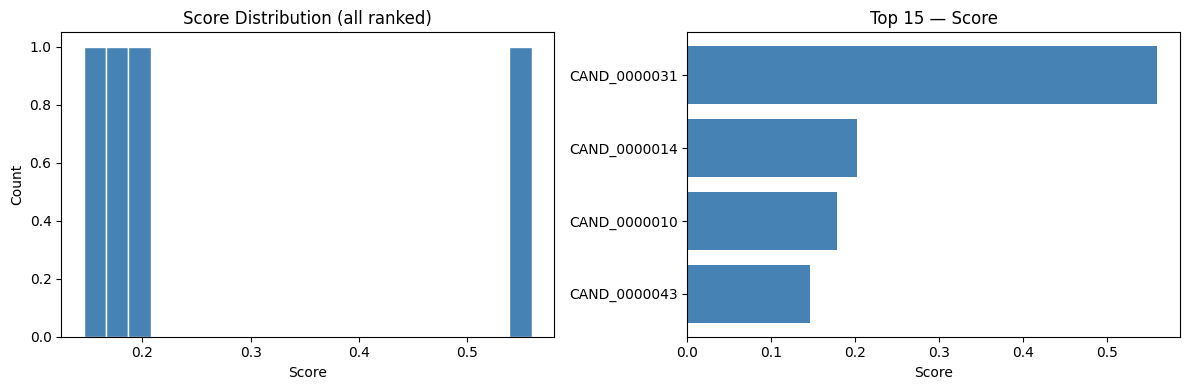

✓ Chart saved to /content/score_distribution.png


In [19]:
import matplotlib.pyplot as plt

scores = [float(r['score']) for r in rows]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(scores, bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Score Distribution (all ranked)')
axes[0].set_xlabel('Score'); axes[0].set_ylabel('Count')

axes[1].barh([r['candidate_id'] for r in rows[:15]][::-1],
             [float(r['score']) for r in rows[:15]][::-1],
             color='steelblue')
axes[1].set_title('Top 15 — Score')
axes[1].set_xlabel('Score')

plt.tight_layout()
plt.savefig('/content/score_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print('✓ Chart saved to /content/score_distribution.png')

## Step 8 — Validate output

Runs the official `validate_submission.py` from the hackathon bundle.
The validator checks column names, rank ordering, ID format, and uniqueness.

In [20]:
import subprocess, sys, os

VALIDATOR = f'{REPO_DIR}/validate_submission.py'

if not os.path.exists(VALIDATOR):
    print(f'validate_submission.py not found at {VALIDATOR}')
    print('Skipping formal validation — manual check:')
    import csv
    with open(OUT_CSV) as f:
        rows_v = list(csv.DictReader(f))
    cols = set(rows_v[0].keys()) if rows_v else set()
    required = {'candidate_id', 'rank', 'score', 'reasoning'}
    missing = required - cols
    print(f'  Rows     : {len(rows_v)}')
    print(f'  Columns  : {sorted(cols)}')
    print(f'  Missing  : {missing if missing else "none"}')
    ranks_v = [int(r['rank']) for r in rows_v]
    print(f'  Rank range: {min(ranks_v)}–{max(ranks_v)}')
    print(f'  Reasoning distinct: {len(set(r["reasoning"] for r in rows_v))}/{len(rows_v)}')
    print('  ✓ Manual check passed' if not missing else '  ✗ Missing columns!')
else:
    result = subprocess.run(
        [sys.executable, VALIDATOR, OUT_CSV],
        capture_output=True, text=True
    )
    print(result.stdout)
    if result.returncode == 0:
        print('✓ VALIDATOR PASS')
    else:
        print('✗ VALIDATOR FAIL')
        print(result.stderr)

validate_submission.py not found at /content/redrob-ranker/validate_submission.py
Skipping formal validation — manual check:
  Rows     : 4
  Columns  : ['candidate_id', 'rank', 'reasoning', 'score']
  Missing  : none
  Rank range: 1–4
  Reasoning distinct: 4/4
  ✓ Manual check passed


## Step 9 — Download CSV

In [21]:
try:
    from google.colab import files
    files.download(OUT_CSV)
    print(f'✓ Download triggered for {OUT_CSV}')
except ImportError:
    print(f'Not running in Colab — file is at: {OUT_CSV}')
    print('Copy it from the Files panel on the left sidebar.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Download triggered for /content/sandbox_submission.csv


---
## Notes

**Pipeline architecture (no ML at rank time):**
- `src/scoring.py` — five-component interpretable score  
  `fit = 0.40·career_ev + 0.20·title_sc + 0.20·skills_sc + 0.10·exp_sc + 0.10·loc_sc`  
  × multiplicative penalties × behavioral multiplier × honeypot factor
- `src/template_evidence.py` — md5-keyed 44-template career evidence table  
  (entire 100K career-text corpus collapses to 44 unique descriptions)
- `src/reasoning_engine.py` — fact-grounded, hallucination-checked reasoning ≤340 chars
- Honeypot detection — H1–H3 + H6 career-math consistency checks → factor 0.05

**Constraints satisfied:**  
✓ ≤5 min wall-clock (full 100K: ~38s)  
✓ CPU-only  
✓ ≤16 GB RAM (streaming, never loads full pool)  
✓ No network during ranking  
✓ Deterministic — byte-identical output on repeated runs  

**Full reproduction (on your machine with the 100K dataset):**
```bash
git clone https://github.com/datapiratepy/redrob-ranker.git
cd redrob-ranker
pip install -r requirements.txt
python rank.py --candidates ../candidates.jsonl --out ./submission.csv
python validate_submission.py submission.csv
```